In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../datasets/play_tennis.csv")
df

,OUTLOOK,TEMPERATURE,HUMIDITY,WIND,PLAY TENNIS
0,sunny,hot,high,weak,no
1,sunny,hot,high,strong,no
2,overcast,hot,high,weak,yes
3,rain,mild,high,weak,yes
4,rain,cool,normal,weak,yes
5,rain,cool,normal,strong,no
6,overcast,cool,normal,strong,yes
7,sunny,mild,high,weak,no
8,sunny,cool,normal,weak,yes
9,rain,mild,normal,weak,yes


In [4]:
# Convert categorical features to numerical using one-hot encoding
df = pd.get_dummies(df, columns=['OUTLOOK', 'TEMPERATURE', 'HUMIDITY', 'WIND']) # Convert categorical columns

In [5]:
# Separate features and target variable
X = df.drop('PLAY TENNIS', axis=1)  
y = df['PLAY TENNIS'] 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
# Separate features and target variable
X = df.drop('PLAY TENNIS', axis=1)  # Features (independent variables)
y = df['PLAY TENNIS'] 

In [8]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
y_pred = model.predict(X_test)

In [10]:

print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))

Accuracy Score :  0.6
Confusion Matrix : 
 [[1 1]
 [1 2]]


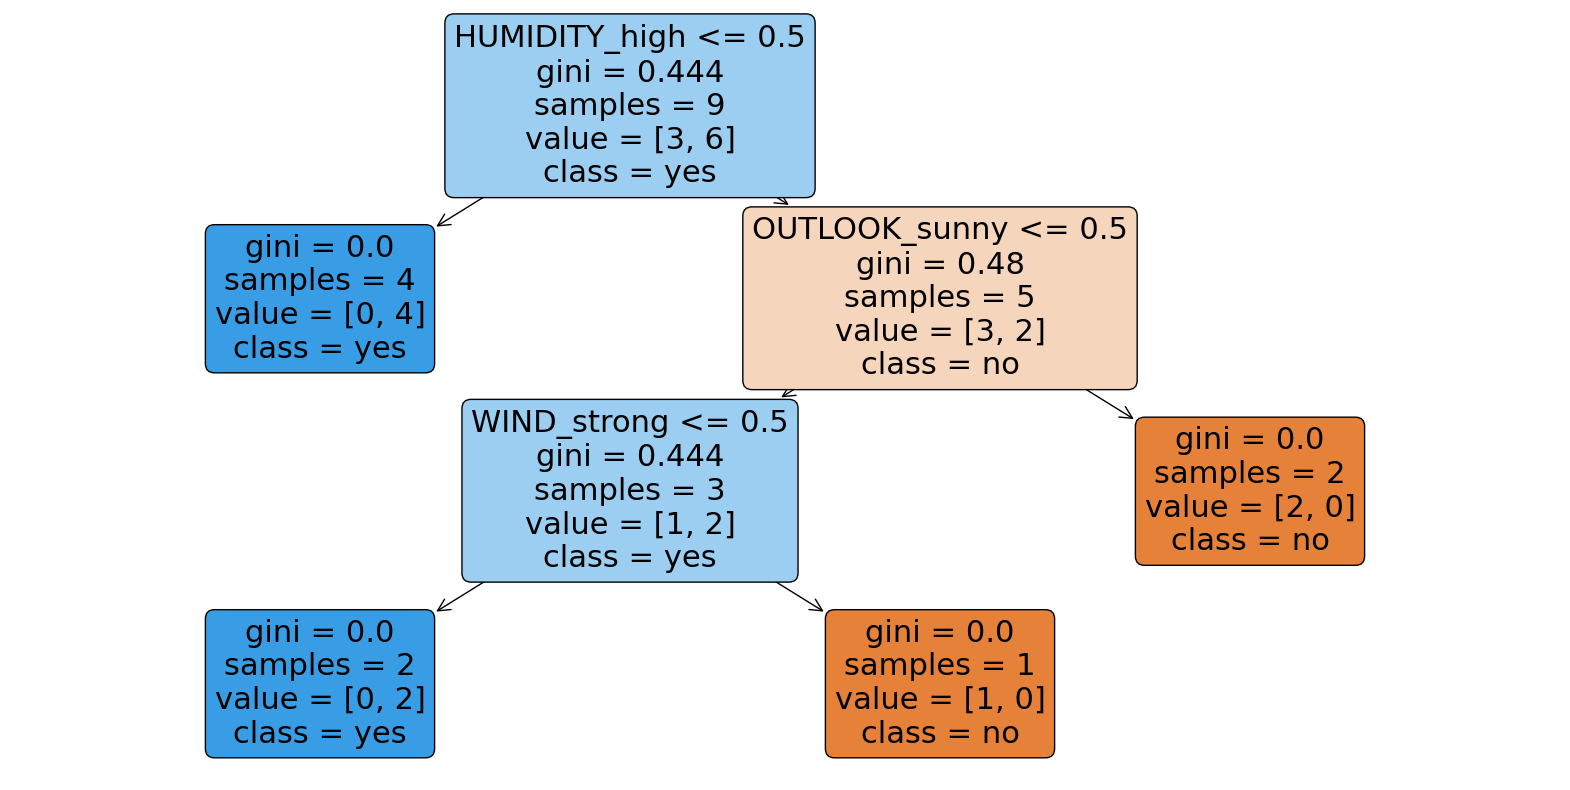

In [11]:
plt.figure(figsize=(20,10))
tree.plot_tree(model, filled=True, feature_names=X.columns, class_names=y.unique().tolist(), rounded=True) # Changed str(y.unique()) to y.unique().tolist()
plt.show()

### With own dataset

In [12]:
df = pd.read_csv("../datasets/Loan_status.csv")
df

,Unnamed: 0,Credit_History,LoanAmount,ApplicantIncome,Loan_Status
0,0,1.0,128.0,5849,Y
1,1,1.0,128.0,4583,N
2,2,1.0,66.0,3000,Y
3,3,1.0,120.0,2583,Y
4,4,1.0,141.0,6000,Y
...,...,...,...,...,...
609,609,1.0,71.0,2900,Y
610,610,1.0,40.0,4106,Y
611,611,1.0,253.0,8072,Y
612,612,1.0,187.0,7583,Y


In [13]:
df.drop(columns=["Unnamed: 0"],inplace=True)

In [14]:
# Replace yes → 1, no → 0
df["Loan_Status"] = df["Loan_Status"].replace({"Y": 1, "N": 0})

In [15]:
x = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]
print(y)

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64


In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
model = DecisionTreeClassifier(random_state=42,max_depth=5)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [28]:
y_pred = model.predict(x_test)

In [29]:
print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))

Accuracy Score :  0.7560975609756098
Confusion Matrix : 
 [[16 27]
 [ 3 77]]


In [30]:
y.dtype

dtype('int64')

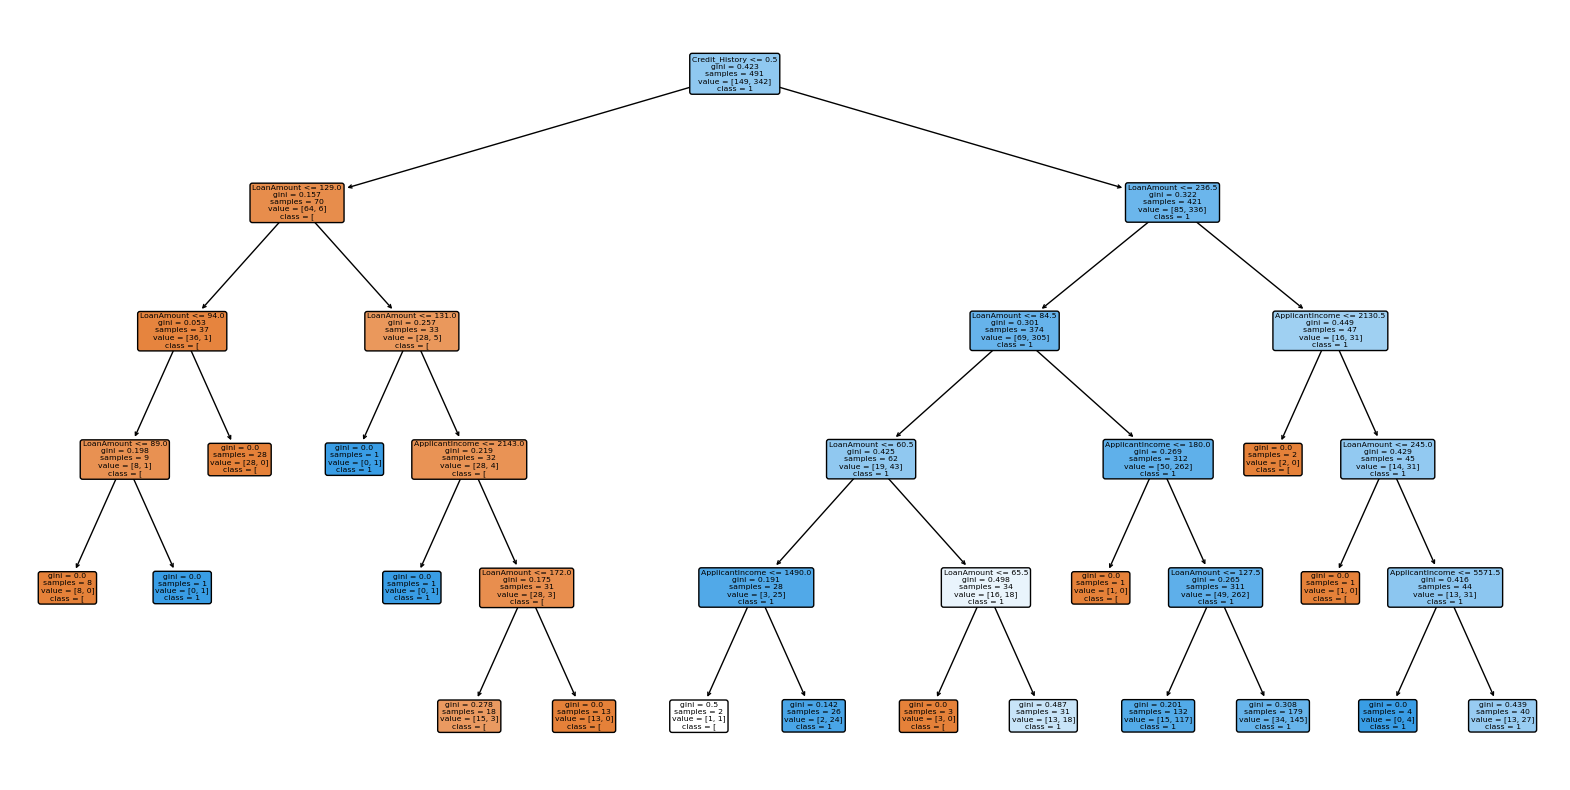

In [31]:
plt.figure(figsize=(20,10))
tree.plot_tree(model, filled=True, feature_names=x.columns, class_names= str(y.unique()), rounded=True) # Changed str(y.unique()) to y.unique().tolist()
plt.show()